# Society presentation figures

`02_main_prefix_comparison_3_2.ipynb` から、スライド掲載用の3図だけを個別に生成します。上から準備セルを一度実行した後、各図のセルを単独で実行してください。

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd

from mawi_global_analysis.comparison import build_comparison_flow_inclusion
from mawi_global_analysis.io import load_run

japanese_font_candidates = ('Hiragino Sans', 'Noto Sans CJK JP', 'Noto Serif CJK JP', 'IPAexGothic', 'YuGothic', 'Meiryo')
available_font_names = {font.name for font in font_manager.fontManager.ttflist}
japanese_font = next((font for font in japanese_font_candidates if font in available_font_names), None)
if japanese_font is None:
    raise RuntimeError('日本語グリフを含むMatplotlibフォントが見つかりません')
plt.rcParams['font.family'] = japanese_font
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['figure.titlesize'] = 16

# スライド用フォントサイズ（必要に応じて、ここだけ変更してください）。
PLOT_TITLE_FONT_SIZE = 20
PLOT_XLABEL_FONT_SIZE = 16
PLOT_YLABEL_FONT_SIZE = 16
# CDFグラフの横長サイズ（幅, 高さ・インチ）。比率を変えたい場合は、ここを変更してください。
PACKET_CDF_FIGSIZE = (8.5, 4.5)

def apply_slide_font_sizes(axis):
    axis.title.set_fontsize(PLOT_TITLE_FONT_SIZE)
    axis.xaxis.label.set_size(PLOT_XLABEL_FONT_SIZE)
    axis.yaxis.label.set_size(PLOT_YLABEL_FONT_SIZE)

def resolve_analysis_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / 'pyproject.toml').is_file() and (candidate / 'src' / 'mawi_global_analysis').is_dir():
            return candidate
    return Path.cwd()

root = resolve_analysis_root().resolve()
dataset_id = '202604081400'
run_name = 'scan_source_driven_removal'
run = load_run(dataset_id, run_name, root=root)

In [2]:
# 元ノートブックと同じ、Raw由来の固定native prefix集合・membershipを構築する。
inclusion = build_comparison_flow_inclusion(run.flows, run.labels)
flow_metrics = run.flows.merge(inclusion, on='flow_id', how='inner', validate='one_to_one')
ipv4_flows = flow_metrics.loc[pd.to_numeric(flow_metrics['ip_version']) == 4]
selected_prefixes = run.prefixes.loc[
    run.prefixes['selected_for_analysis'] == True,
    ['prefix', 'prefix_length', 'seen_as_src_prefix', 'seen_as_dst_prefix'],
].copy()
native_membership = run.membership.loc[run.membership['analysis_scope'] == 'native'].copy()
selected_prefix_ids = set(selected_prefixes['prefix'])
if not set(native_membership['flow_id']).issubset(set(inclusion['flow_id'])):
    raise ValueError('native membershipにcanonical flow集合の外部のflow_idが含まれています')
if not set(native_membership['analysis_prefix']).issubset(selected_prefix_ids):
    raise ValueError('native membershipに固定Raw由来選択集合の外部のprefixが含まれています')
prefix_flow_columns = ['flow_id', 'packet_count', 'frame_byte_count', 'ip_byte_count', 'duration', 'raw_included', 'strict_included', 'broad_included']
prefix_flows = native_membership.merge(
    ipv4_flows.loc[:, prefix_flow_columns], on='flow_id', how='inner', validate='many_to_one'
)
selected_scope_flows = ipv4_flows.loc[ipv4_flows['flow_id'].isin(native_membership['flow_id'].unique())]

In [3]:
# 元ノートブックと同じRaw / Broad集計。
conditions = pd.DataFrame({'condition': ['Raw', 'Broad'], 'inclusion_column': ['raw_included', 'broad_included']})
count_columns = ['flow_count', 'packet_count', 'frame_byte_count']

def safe_ratio(numerator, denominator):
    return numerator.div(denominator.where(denominator > 0))

prefix_condition_index = selected_prefixes.loc[:, ['prefix']].rename(columns={'prefix': 'analysis_prefix'}).merge(
    conditions.loc[:, ['condition', 'inclusion_column']], how='cross'
)
prefix_condition_metrics = []
for row in conditions.itertuples(index=False):
    survivors = prefix_flows.loc[prefix_flows[row.inclusion_column]]
    metrics = survivors.groupby('analysis_prefix', as_index=False).agg(
        flow_count=('flow_id', 'size'),
        packet_count=('packet_count', 'sum'),
        frame_byte_count=('frame_byte_count', 'sum'),
        median_packet_count=('packet_count', 'median'),
        median_frame_byte_count=('frame_byte_count', 'median'),
        median_duration=('duration', 'median'),
    )
    metrics['condition'] = row.condition
    prefix_condition_metrics.append(metrics)
per_prefix_condition_summary = prefix_condition_index.drop(columns='inclusion_column').merge(
    pd.concat(prefix_condition_metrics, ignore_index=True),
    on=['analysis_prefix', 'condition'],
    how='left',
    validate='one_to_one',
)
per_prefix_condition_summary.loc[:, count_columns] = per_prefix_condition_summary.loc[:, count_columns].fillna(0)

median_metrics = ['median_packet_count', 'median_frame_byte_count', 'median_duration']
raw_prefix_comparison = per_prefix_condition_summary.loc[
    per_prefix_condition_summary['condition'] == 'Raw', ['analysis_prefix', 'flow_count', *median_metrics]
].rename(columns={'flow_count': 'raw_flow_count', **{metric: f'raw_{metric}' for metric in median_metrics}})
broad_prefix_comparison = per_prefix_condition_summary.loc[
    per_prefix_condition_summary['condition'] == 'Broad', ['analysis_prefix', 'flow_count', *median_metrics]
].rename(columns={'flow_count': 'broad_flow_count', **{metric: f'broad_{metric}' for metric in median_metrics}})
prefix_broad_comparison = raw_prefix_comparison.merge(
    broad_prefix_comparison, on='analysis_prefix', how='inner', validate='one_to_one'
)
prefix_broad_comparison['packet_change_rate'] = safe_ratio(
    prefix_broad_comparison['broad_median_packet_count'] - prefix_broad_comparison['raw_median_packet_count'],
    prefix_broad_comparison['raw_median_packet_count'],
).mul(100)

def ecdf(values):
    ordered = np.sort(np.asarray(values, dtype=float))
    return ordered, np.arange(1, len(ordered) + 1) / len(ordered)

protocol_values = ['6', '6.0', 'tcp', '17', '17.0', 'udp']
packet_cdf_scopes = [
    ('全トラフィック', ipv4_flows, 'tab:orange', '-'),
    ('プレフィックストラフィック', selected_scope_flows, 'tab:green', '-'),
]

def packet_cdf_series(condition):
    inclusion_column = conditions.loc[conditions['condition'] == condition, 'inclusion_column'].iloc[0]
    series = []
    for scope, frame, color, style in packet_cdf_scopes:
        packets = pd.to_numeric(
            frame.loc[frame[inclusion_column] & frame['protocol'].astype(str).isin(protocol_values), 'packet_count'],
            errors='coerce',
        ).dropna()
        series.append({'scope': scope, 'color': color, 'style': style, 'label': scope, 'packets': packets})
    return series

raw_packet_cdf_series = packet_cdf_series('Raw')
broad_packet_cdf_series = packet_cdf_series('Broad')
all_packet_counts = pd.concat(
    [item['packets'] for item in [*raw_packet_cdf_series, *broad_packet_cdf_series] if not item['packets'].empty],
    ignore_index=True,
)
if all_packet_counts.empty:
    raise ValueError('Raw / Broadのpacket_count分布を描画できるflowがありません')
common_packet_x_limits = (float(all_packet_counts.min()), float(all_packet_counts.max()))

## 1. フローあたりパケット数の中央値変化率

このセルだけを実行すると、スライド用の単一グラフを生成します。

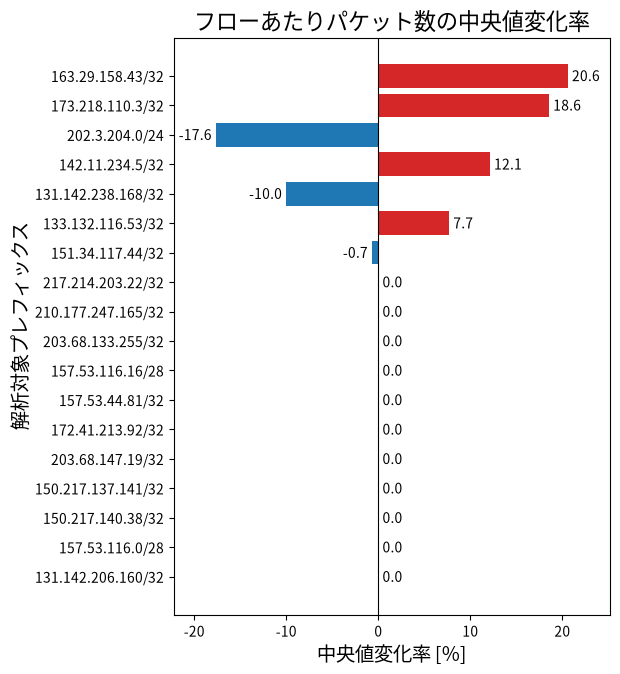

In [4]:
ranked = prefix_broad_comparison.dropna(subset=['packet_change_rate']).sort_values(
    'packet_change_rate', key=lambda values: values.abs()
)
fig, axis = plt.subplots(figsize=(6.3, max(5, len(prefix_broad_comparison) * 0.38)))
if ranked.empty:
    axis.text(0.5, 0.5, '比較可能なプレフィックス中央値はありません', ha='center', va='center', transform=axis.transAxes)
else:
    colors = np.where(ranked['packet_change_rate'] >= 0, 'tab:red', 'tab:blue')
    bars = axis.barh(ranked['analysis_prefix'], ranked['packet_change_rate'], color=colors)
    axis.bar_label(bars, labels=[f'{value:.1f}' for value in ranked['packet_change_rate']], padding=3)
    axis.margins(x=0.12)
    axis.axvline(0, color='black', linewidth=0.8)
axis.set(
    title='フローあたりパケット数の中央値変化率',
    xlabel='中央値変化率 [%]',
    ylabel='解析対象プレフィックス',
)
apply_slide_font_sizes(axis)
fig.tight_layout()
plt.show()

## 2. 除外前：パケット数のCDF

step histogramは含めません。

/tmp/ipykernel_264950/2147716368.py:17: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/home/s-sakai/mawi-global-analysis/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


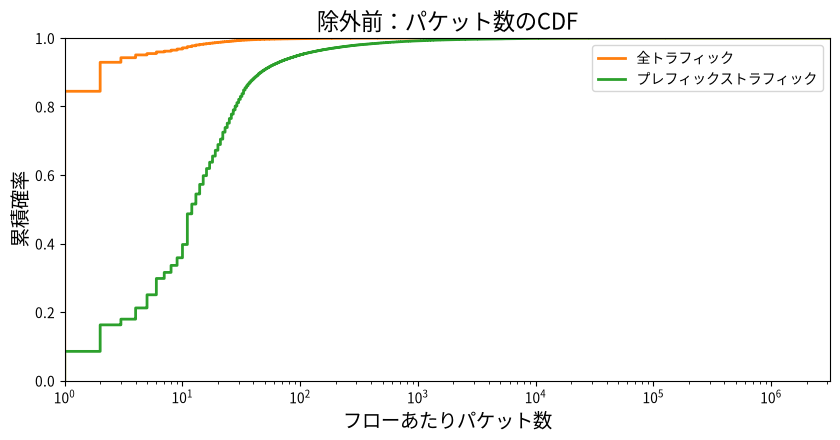

In [5]:
fig, axis = plt.subplots(figsize=PACKET_CDF_FIGSIZE)
for item in raw_packet_cdf_series:
    if item['packets'].empty:
        continue
    x, y = ecdf(item['packets'])
    axis.step(x, y, where='post', linewidth=2, color=item['color'], linestyle=item['style'], label=item['label'])
axis.set(
    title='除外前：パケット数のCDF',
    xlabel='フローあたりパケット数',
    ylabel='累積確率',
    xscale='log',
    xlim=common_packet_x_limits,
    ylim=(0, 1),
)
apply_slide_font_sizes(axis)
axis.legend()
fig.tight_layout()
plt.show()

## 3. 除外後：パケット数のCDF

step histogramは含めません。

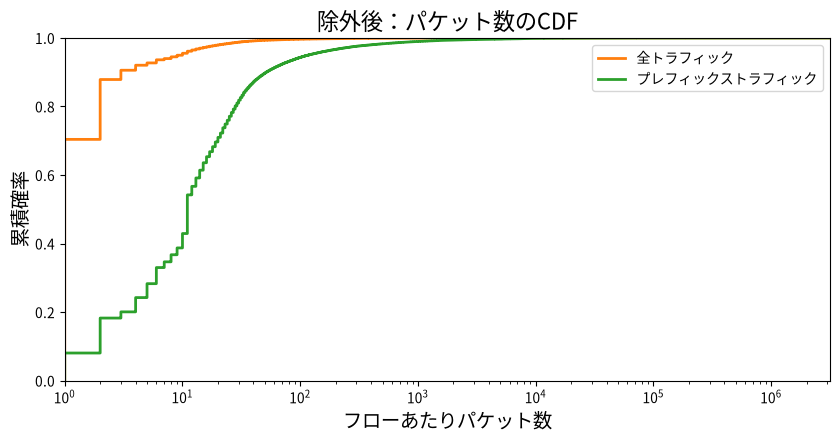

In [6]:
fig, axis = plt.subplots(figsize=PACKET_CDF_FIGSIZE)
# 除外前は同じ色の点線で重ね、除外後の実線と比較する。
for item in raw_packet_cdf_series:
    if item['packets'].empty:
        continue
    x, y = ecdf(item['packets'])
    axis.step(x, y, where='post', linewidth=2, color=item['color'], linestyle=':', alpha=1.0, label=f'除外前：{item['label']}')
for item in broad_packet_cdf_series:
    if item['packets'].empty:
        continue
    x, y = ecdf(item['packets'])
    axis.step(x, y, where='post', linewidth=2, color=item['color'], linestyle=item['style'], label=item['label'])
axis.set(
    title='除外後：パケット数のCDF',
    xlabel='フローあたりパケット数',
    ylabel='累積確率',
    xscale='log',
    xlim=common_packet_x_limits,
    ylim=(0, 1),
)
apply_slide_font_sizes(axis)
axis.legend()
fig.tight_layout()
plt.show()